# MSc Thesis - Predicting bacterial lineage and antimicrobial resistance from whole-genome sequences

**Goal:** given a bacterial genome, predict its evolutionary lineage and its resistance to specific drug classes.

For the full narrative (methodological decisions, results and limitations), see the project [README](../README.md).

# Phase 0: Environment setup

In [ ]:
!pip install -q biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 20.6 MB/s eta 0:00:00


In [ ]:
import os
import re
import json
import glob
import time
import shutil
import gzip
import tarfile
import subprocess
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from itertools import product
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix, average_precision_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils.class_weight import compute_sample_weight

## Configure the data folder

This repository ships the small metadata/target CSVs used in Phase 4-6 under `data/` (see the README). The full set of downloaded genomes and the generated feature matrices are not published; point `DATA_DIR` below at wherever you keep your own copy to regenerate them by re-running phases 1 and 6.

In [ ]:
DATA_DIR = "./data"  # set this to your own data folder
os.makedirs(DATA_DIR, exist_ok=True)


# Phase 1: Metadata and genome retrieval

## 1.1 Install the NCBI `datasets` CLI

In [ ]:
!curl -s -o datasets 'https://ftp.ncbi.nlm.nih.gov/pub/datasets/command-line/v2/linux-amd64/datasets'
!chmod +x datasets
!mv datasets /usr/local/bin/
!apt-get install -y unzip -qq
!datasets version


datasets version: 18.36.0


## 1.2 Metadata from NCBI

In [ ]:
especies = [
    {"nombre": "Staphylococcus aureus", "limite": 500},
    {"nombre": "Klebsiella pneumoniae", "limite": 500},
    {"nombre": "Escherichia coli", "limite": 500},
]

filas_totales = []
print("Consultando metadatos en NCBI...")

for sp in especies:
    nombre_esp, lim = sp["nombre"], sp["limite"]
    print(f" Buscando registros para: {nombre_esp} (objetivo: {lim})...")

    cmd = ["datasets", "summary", "genome", "taxon", nombre_esp,
           "--assembly-level", "complete", "--limit", "700"]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        print(f" Error al consultar {nombre_esp}: {res.stderr}")
        continue

    try:
        data = json.loads(res.stdout)
    except json.JSONDecodeError:
        print(f" Error al procesar JSON para {nombre_esp}")
        continue

    records = data.get("reports", [])
    filas_especie = []
    firmas_resistentes = ["resistant", "mrsa", "kpc", "ndm", "ctx-m", "esbl",
                          "carbapenem-resistant", "multidrug-resistant"]

    for r in records:
        if len(filas_especie) >= lim:
            break
        accession = r.get("accession")
        descriptors = r.get("assembly_info", {})
        title = descriptors.get("title", "").lower()
        organism_info = str(r.get("organism", {})).lower()

        es_resistente = any(f in title or f in organism_info for f in firmas_resistentes)
        label = 1 if es_resistente else (1 if len(filas_especie) % 2 == 0 else 0)

        filas_especie.append({"id_sample": accession, "organism": nombre_esp, "target": label})

    print(f"  -> Muestras obtenidas: {len(filas_especie)}")
    filas_totales.extend(filas_especie)

csv_path = os.path.join(DATA_DIR, "metadata_1500.csv")
df_1500 = pd.DataFrame(filas_totales)
df_1500.to_csv(csv_path, index=False)
print(f"Metadatos listos ({len(df_1500)} registros) en {csv_path}")


## 1.3 Parallel download of complete genomes

In [ ]:
LOCAL_FASTA_DIR = "/content/fasta_1500"
MAX_WORKERS = 8
os.makedirs(LOCAL_FASTA_DIR, exist_ok=True)

def descargar_genoma(accession):
    out_fasta = os.path.join(LOCAL_FASTA_DIR, f"{accession}.fasta")
    if os.path.exists(out_fasta) and os.path.getsize(out_fasta) > 0:
        return accession, "EXISTE"

    zip_file = f"/tmp/{accession}.zip"
    tmp_dir = f"/tmp/{accession}_tmp"
    cmd = ["datasets", "download", "genome", "accession", accession,
           "--include", "genome", "--filename", zip_file]
    res = subprocess.run(cmd, capture_output=True, text=True)

    if res.returncode == 0 and os.path.exists(zip_file):
        subprocess.run(["unzip", "-q", "-o", zip_file, "-d", tmp_dir], capture_output=True)
        found = False
        for root, _, files in os.walk(tmp_dir):
            for file in files:
                if file.endswith((".fna", ".fasta")):
                    shutil.move(os.path.join(root, file), out_fasta)
                    found = True
                    break
            if found:
                break
        if os.path.exists(zip_file):
            os.remove(zip_file)
        if os.path.exists(tmp_dir):
            shutil.rmtree(tmp_dir, ignore_errors=True)
        return (accession, "OK") if found else (accession, "ERROR_SIN_FASTA")
    else:
        if os.path.exists(zip_file):
            os.remove(zip_file)
        if os.path.exists(tmp_dir):
            shutil.rmtree(tmp_dir, ignore_errors=True)
        return accession, "ERROR_DESCARGA"

accessions = df_1500["id_sample"].tolist()
total = len(accessions)
print(f"Descargando {total} genomas ({MAX_WORKERS} hilos)...")

completados = omitidos = errores = 0
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(descargar_genoma, acc): acc for acc in accessions}
    for i, future in enumerate(as_completed(futures), 1):
        acc, estado = future.result()
        completados += estado == "OK"
        omitidos += estado == "EXISTE"
        errores += estado not in ("OK", "EXISTE")
        if i % 100 == 0 or i == total:
            print(f" Progreso: [{i}/{total}] OK={completados} | Omitidos={omitidos} | Errores={errores}", flush=True)

print(f"Descarga finalizada: {len(os.listdir(LOCAL_FASTA_DIR))} genomas locales.")


Descargando 1500 genomas (8 hilos)...
 Progreso: [100/1500] OK=99 | Omitidos=0 | Errores=1
 Progreso: [200/1500] OK=113 | Omitidos=86 | Errores=1
 Progreso: [300/1500] OK=154 | Omitidos=138 | Errores=8
 Progreso: [400/1500] OK=242 | Omitidos=142 | Errores=16
 Progreso: [500/1500] OK=323 | Omitidos=147 | Errores=30
 Progreso: [600/1500] OK=423 | Omitidos=147 | Errores=30
 Progreso: [700/1500] OK=522 | Omitidos=147 | Errores=31
 Progreso: [800/1500] OK=622 | Omitidos=147 | Errores=31
 Progreso: [900/1500] OK=722 | Omitidos=147 | Errores=31
 Progreso: [1000/1500] OK=821 | Omitidos=147 | Errores=32
 Progreso: [1100/1500] OK=921 | Omitidos=147 | Errores=32
 Progreso: [1200/1500] OK=1021 | Omitidos=147 | Errores=32
 Progreso: [1300/1500] OK=1120 | Omitidos=147 | Errores=33
 Progreso: [1400/1500] OK=1218 | Omitidos=147 | Errores=35
 Progreso: [1500/1500] OK=1318 | Omitidos=147 | Errores=35
Descarga finalizada: 2463 genomas locales.


*(Local scratch files from earlier test runs; cleaned up below.)*

### 1.3.1 Diagnose and retry failed accessions

In [ ]:
def descargar_genoma_debug(accession):
    out_fasta = os.path.join(LOCAL_FASTA_DIR, f"{accession}.fasta")
    if os.path.exists(out_fasta) and os.path.getsize(out_fasta) > 0:
        return accession, "EXISTE", ""

    zip_file = f"/tmp/{accession}.zip"
    tmp_dir = f"/tmp/{accession}_tmp"
    cmd = ["datasets", "download", "genome", "accession", accession,
           "--include", "genome", "--filename", zip_file]
    res = subprocess.run(cmd, capture_output=True, text=True)

    if res.returncode == 0 and os.path.exists(zip_file):
        subprocess.run(["unzip", "-q", "-o", zip_file, "-d", tmp_dir], capture_output=True)
        found = False
        for root, _, files in os.walk(tmp_dir):
            for file in files:
                if file.endswith((".fna", ".fasta")):
                    shutil.move(os.path.join(root, file), out_fasta)
                    found = True
                    break
            if found:
                break
        if os.path.exists(zip_file): os.remove(zip_file)
        if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir, ignore_errors=True)
        return (accession, "OK", "") if found else (accession, "ERROR_SIN_FASTA", "zip sin .fna/.fasta dentro")
    else:
        if os.path.exists(zip_file): os.remove(zip_file)
        if os.path.exists(tmp_dir): shutil.rmtree(tmp_dir, ignore_errors=True)
        return accession, "ERROR_DESCARGA", res.stderr.strip()[:300]

# Identifica qué accesiones del CSV no tienen fasta descargado
accessions = df_1500["id_sample"].tolist()
existentes = {f.replace(".fasta", "") for f in os.listdir(LOCAL_FASTA_DIR) if f.endswith(".fasta")}
fallidas = [a for a in accessions if a not in existentes]
print(f"Accesiones sin descargar: {len(fallidas)}")

# Reintento con menos hilos
resultados_debug = []
with ThreadPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(descargar_genoma_debug, acc): acc for acc in fallidas}
    for future in as_completed(futures):
        resultados_debug.append(future.result())

df_errores = pd.DataFrame(resultados_debug, columns=["id_sample", "estado", "motivo"])
print(df_errores["estado"].value_counts())
print(df_errores[df_errores["estado"] != "OK"]["motivo"].value_counts().head(10))
df_errores.to_csv(os.path.join(DATA_DIR, "descarga_errores.csv"), index=False)

Accesiones sin descargar: 19
estado
OK    19
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


## 1.4 Post-download cleanup

In [ ]:
CSV_PATH = os.path.join(DATA_DIR, "metadata_1500.csv")
CLEAN_CSV_PATH = os.path.join(DATA_DIR, "metadata_clean.csv")

df = pd.read_csv(CSV_PATH)
archivos_existentes = {f.replace(".fasta", "") for f in os.listdir(LOCAL_FASTA_DIR) if f.endswith(".fasta")}
df_clean = df[df["id_sample"].isin(archivos_existentes)].copy()
df_clean.to_csv(CLEAN_CSV_PATH, index=False)

print(f"Muestras iniciales: {len(df)} | FASTA reales en disco: {len(archivos_existentes)} | Dataset limpio: {len(df_clean)}")
print(df_clean["organism"].value_counts())


Muestras iniciales: 1500 | FASTA reales en disco: 2768 | Dataset limpio: 1500
organism
Staphylococcus aureus    500
Klebsiella pneumoniae    500
Escherichia coli         500
Name: count, dtype: int64


## 1.5 Copy the working subset locally

In [ ]:
FASTA_DIR = os.path.join(DATA_DIR, "fasta_1500")
os.makedirs(FASTA_DIR, exist_ok=True)

df_subset = pd.read_csv(CLEAN_CSV_PATH)
copiados = faltantes = 0
for acc in df_subset["id_sample"]:
    src = os.path.join(LOCAL_FASTA_DIR, f"{acc}.fasta")
    dst = os.path.join(FASTA_DIR, f"{acc}.fasta")
    if os.path.exists(dst) and os.path.getsize(dst) > 0:
        continue
    if os.path.exists(src):
        shutil.copy2(src, dst)
        copiados += 1
    else:
        faltantes += 1

print(f"Copiados: {copiados} | Faltantes: {faltantes} | Total local: {len(os.listdir(FASTA_DIR))}")


Copiados: 731 | Faltantes: 0 | Total local: 2231


### 1.5.1 Clean up extra files

In [ ]:
df_subset = pd.read_csv(CLEAN_CSV_PATH)
ids_esperados = set(df_subset["id_sample"])
print(f"IDs esperados en el subconjunto actual: {len(ids_esperados)}")

archivos_local = os.listdir(FASTA_DIR)
ids_en_local = {f.replace(".fasta", "") for f in archivos_local}

faltantes = ids_esperados - ids_en_local
sobrantes = ids_en_local - ids_esperados

print(f"Archivos en local: {len(archivos_local)}")
print(f"Faltantes (esperados pero no están): {len(faltantes)}")
print(f"Sobrantes (en local pero no pertenecen al subconjunto actual): {len(sobrantes)}")

IDs esperados en el subconjunto actual: 1500
Archivos en local: 2231
Faltantes (esperados pero no están): 0
Sobrantes (en local pero no pertenecen al subconjunto actual): 731


In [ ]:
eliminados = 0
for acc in sobrantes:
    path = os.path.join(FASTA_DIR, f"{acc}.fasta")
    if os.path.exists(path):
        os.remove(path)
        eliminados += 1

print(f"Eliminados: {eliminados} | Total ahora local: {len(os.listdir(FASTA_DIR))}")

Eliminados: 731 | Total ahora local: 1500


# Phase 2: Resistance gene detection (Abricate + CARD)

Abricate compares each genome against the CARD reference sequences and returns, for every hit, its genome position, gene, identity, coverage and the drug class it confers resistance to (`RESISTANCE` column).

## 2.1 Install Abricate and the CARD database

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()



📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


In [ ]:
!mamba install -y -c bioconda -c conda-forge abricate
!abricate --version
!abricate --list
!abricate-get_db --db card --force


[+] 0.0s
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch     1%
bioconda/linux-64     ⣾  
bioconda/noarch       ⣾  [+] 0.2s
conda-forge/linux-64   4%
conda-forge/noarch     8%
bioconda/linux-64     19%
bioconda/noarch       12%[+] 0.3s
conda-forge/linux-64   7%
conda-forge/noarch    14%
bioconda/linux-64     49%
bioconda/noarch       39%[+] 0.4s
conda-forge/linux-64   8%
conda-forge/noarch    17%
bioconda/linux-64     62%
bioconda/noarch       51%[+] 0.5s
conda-forge/linux-64  10%
conda-forge/noarch    20%
bioconda/linux-64     77%
bioconda/noarch       73%[+] 0.6s
conda-forge/linux-64  11%
conda-forge/noarch    22%
bioconda/linux-64     90%
bioconda/noarch       86%bioconda/linux-64                                 
[+] 0.7s
conda-forge/linux-64  12%
conda-forge/noarch    25%
bioconda/noarch       98%bioconda/noarch                                   
[+] 0.8s
conda-forge/linux-64  13%
conda-forge/noarch    26%[+] 0.9s
conda-forge/linux-64  17%
conda-forge/noarch    34%[+

*(This step restarts the Colab session; imports and the data folder path are redefined below.)*

In [ ]:
import os
import re
import json
import glob
import time
import shutil
import gzip
import tarfile
import subprocess
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from itertools import product
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix, average_precision_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
DATA_DIR = "./data"  # set this to your own data folder
os.makedirs(DATA_DIR, exist_ok=True)

# Fase 1
LOCAL_FASTA_DIR = "/content/fasta_1500"
CSV_PATH = os.path.join(DATA_DIR, "metadata_1500.csv")
CLEAN_CSV_PATH = os.path.join(DATA_DIR, "metadata_clean.csv")
SUBSET_CSV_PATH = os.path.join(DATA_DIR, "metadata_1500.csv")
FASTA_DIR = os.path.join(DATA_DIR, "fasta_1500")

# Fase 2
OUTPUT_ARG_DIR = os.path.join(DATA_DIR, "fasta_arg")
HITS_CSV_PATH = os.path.join(DATA_DIR, "abricate_hits.csv")

print("Rutas reconstruidas. FASTA_DIR:", FASTA_DIR)
print("Existe:", os.path.exists(FASTA_DIR), "| Archivos:", len(os.listdir(FASTA_DIR)) if os.path.exists(FASTA_DIR) else 0)

## 2.2 ARG extraction

In [ ]:
INPUT_FASTA_DIR = os.path.join(DATA_DIR, "fasta_1500")
OUTPUT_ARG_DIR = os.path.join(DATA_DIR, "fasta_arg")
HITS_CSV_PATH = os.path.join(DATA_DIR, "abricate_hits.csv")
SUBSET_CSV_PATH = os.path.join(DATA_DIR, "metadata_1500.csv")
DB_NAME = "card"
MAX_WORKERS = os.cpu_count()

os.makedirs(OUTPUT_ARG_DIR, exist_ok=True)

# Columnas del TSV de abricate (formato estándar):
ABRICATE_COLS = ["FILE", "SEQUENCE", "START", "END", "STRAND", "GENE", "COVERAGE",
                  "COVERAGE_MAP", "GAPS", "%COVERAGE", "%IDENTITY", "DATABASE",
                  "ACCESSION", "PRODUCT", "RESISTANCE"]

def process_single_fasta(fasta_path):
    sample_id = os.path.basename(fasta_path).replace(".fasta", "")
    out_fasta = os.path.join(OUTPUT_ARG_DIR, f"{sample_id}.fasta")
    out_hits = os.path.join(OUTPUT_ARG_DIR, f"{sample_id}.hits.csv")

    if os.path.exists(out_fasta) and os.path.exists(out_hits):
        return sample_id, "SKIPPED"

    cmd = ["abricate", "--db", DB_NAME, fasta_path]
    result = subprocess.run(cmd, capture_output=True, text=True)
    lines = result.stdout.strip().split("\n")

    if len(lines) <= 1:
        open(out_fasta, "w").close()
        pd.DataFrame(columns=ABRICATE_COLS).to_csv(out_hits, index=False)
        return sample_id, "NO_ARGS"

    header = lines[0].lstrip("#").split("\t")
    rows = [dict(zip(header, l.split("\t"))) for l in lines[1:]]
    df_hits = pd.DataFrame(rows)
    df_hits["id_sample"] = sample_id
    df_hits.to_csv(out_hits, index=False)

    records = {rec.id: rec for rec in SeqIO.parse(fasta_path, "fasta")}
    extracted_seqs = []
    for row in rows:
        chrom, start, end, gene_name = row["SEQUENCE"], int(row["START"]), int(row["END"]), row["GENE"]
        if chrom in records:
            sub_rec = records[chrom][start - 1:end]
            sub_rec.id = f"{sample_id}_{gene_name}_{start}_{end}"
            sub_rec.description = f"ARG_gene:{gene_name}"
            extracted_seqs.append(sub_rec)

    if extracted_seqs:
        SeqIO.write(extracted_seqs, out_fasta, "fasta")
    else:
        open(out_fasta, "w").close()
    return sample_id, "PROCESSED"

df_subset = pd.read_csv(SUBSET_CSV_PATH)
ids_subset = set(df_subset["id_sample"])
fasta_files = sorted([f for f in glob.glob(os.path.join(INPUT_FASTA_DIR, "*.fasta"))
                       if os.path.basename(f).replace(".fasta", "") in ids_subset])

print(f"Procesando {len(fasta_files)} archivos...")
skipped = processed = 0
with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(process_single_fasta, f): f for f in fasta_files}
    for idx, future in enumerate(as_completed(futures), 1):
        _, res = future.result()
        skipped += res == "SKIPPED"
        processed += res != "SKIPPED"
        if idx % 50 == 0 or idx == len(fasta_files):
            print(f" Progreso: {idx}/{len(fasta_files)} | Omitidos={skipped} | Procesados={processed}")

print("Extracción completa.")


Procesando 1500 archivos...
 Progreso: 50/1500 | Omitidos=50 | Procesados=0
 Progreso: 100/1500 | Omitidos=100 | Procesados=0
 Progreso: 150/1500 | Omitidos=150 | Procesados=0
 Progreso: 200/1500 | Omitidos=200 | Procesados=0
 Progreso: 250/1500 | Omitidos=250 | Procesados=0
 Progreso: 300/1500 | Omitidos=300 | Procesados=0
 Progreso: 350/1500 | Omitidos=350 | Procesados=0
 Progreso: 400/1500 | Omitidos=400 | Procesados=0
 Progreso: 450/1500 | Omitidos=450 | Procesados=0
 Progreso: 500/1500 | Omitidos=500 | Procesados=0
 Progreso: 550/1500 | Omitidos=550 | Procesados=0
 Progreso: 600/1500 | Omitidos=600 | Procesados=0
 Progreso: 650/1500 | Omitidos=650 | Procesados=0
 Progreso: 700/1500 | Omitidos=700 | Procesados=0
 Progreso: 750/1500 | Omitidos=750 | Procesados=0
 Progreso: 800/1500 | Omitidos=800 | Procesados=0
 Progreso: 850/1500 | Omitidos=850 | Procesados=0
 Progreso: 900/1500 | Omitidos=900 | Procesados=0
 Progreso: 950/1500 | Omitidos=947 | Procesados=3
 Progreso: 1000/1500 | O

## 2.3 Consolidate all hits into a single table

Merge the per-sample `.hits.csv` files into one table for the downstream steps.

In [ ]:
hits_files = glob.glob(os.path.join(OUTPUT_ARG_DIR, "*.hits.csv"))
df_hits_all = pd.concat([pd.read_csv(f) for f in hits_files], ignore_index=True)
df_hits_all.to_csv(HITS_CSV_PATH, index=False)

print(f"Total de hits ARG registrados: {len(df_hits_all)} (de {df_hits_all['id_sample'].nunique()} muestras)")
df_hits_all.head()


Total de hits ARG registrados: 52068 (de 1500 muestras)


,FILE,SEQUENCE,START,END,STRAND,GENE,COVERAGE,COVERAGE_MAP,GAPS,%COVERAGE,%IDENTITY,DATABASE,ACCESSION,PRODUCT,RESISTANCE,id_sample
0,/content/drive/MyDrive/data/fasta_1500/GCF_003...,NZ_CP034053.1,215137,216861,+,eptB,1-1725/1725,===============,0/0,100.00,99.65,card,FO203501.1:5123640-5125365,eptB is a phosphoethanolamine transferase. It ...,nonribosomal_peptides;peptide,GCF_003855335.1
1,/content/drive/MyDrive/data/fasta_1500/GCF_003...,NZ_CP034053.1,295400,297055,+,ArnT,1-1656/1656,===============,0/0,100.00,99.82,card,FO834906.1:304977-306633,ArnT is involved in Cell Wall Biosynthesis spe...,nonribosomal_peptides;peptide,GCF_003855335.1
2,/content/drive/MyDrive/data/fasta_1500/GCF_003...,NZ_CP034053.1,407678,408310,-,CRP,1-633/633,===============,0/0,100.00,87.84,card,AP009048.1:4154296-4153663,CRP is a global regulator that represses MdtEF...,fluoroquinolone;macrolide;penicillin_beta-lactam,GCF_003855335.1
3,/content/drive/MyDrive/data/fasta_1500/GCF_003...,NZ_CP034053.1,1172029,1173566,-,Klebsiella_pneumoniae_KpnH,1-1538/1539,========/======,2/2,99.87,84.34,card,ASTU01000063.1:61248-62787,KpnH consists of ~511 residues resembles EmrB ...,aminoglycoside;carbapenem;cephalosporin;fluoro...,GCF_003855335.1
4,/content/drive/MyDrive/data/fasta_1500/GCF_003...,NZ_CP034053.1,1173582,1174754,-,Klebsiella_pneumoniae_KpnG,1-1173/1173,===============,0/0,100.00,99.32,card,ACWO01000051.1:22092-23265,KpnG consists of ~390 residues and resembles E...,aminoglycoside;carbapenem;cephalosporin;fluoro...,GCF_003855335.1


## 2.4 Sanity checks

In [ ]:
archivos = os.listdir(OUTPUT_ARG_DIR)
fastas = [f for f in archivos if f.endswith(".fasta")]
vacios = sum(1 for f in fastas if os.path.getsize(os.path.join(OUTPUT_ARG_DIR, f)) == 0)

df_subset = pd.read_csv(SUBSET_CSV_PATH)
ids_esperados = set(df_subset["id_sample"])
ids_procesados = {f.replace(".fasta", "") for f in fastas}

print(f"Archivos .fasta: {len(fastas)} | Vacíos (sin ARG detectado): {vacios} | Con contenido: {len(fastas) - vacios}")
print(f"Faltantes respecto al subconjunto esperado: {len(ids_esperados - ids_procesados)}")
print(f"Sobrantes (de tandas anteriores, a ignorar): {len(ids_procesados - ids_esperados)}")


Archivos .fasta: 2231 | Vacíos (sin ARG detectado): 0 | Con contenido: 2231
Faltantes respecto al subconjunto esperado: 0
Sobrantes (de tandas anteriores, a ignorar): 731


*(Extra files from earlier test runs; cleaned up below.)*

### 2.4.1 Cleanup

In [ ]:
df_subset = pd.read_csv(SUBSET_CSV_PATH)
ids_esperados = set(df_subset["id_sample"])

archivos = os.listdir(OUTPUT_ARG_DIR)

def extraer_id(filename):
    if filename.endswith(".hits.csv"):
        return filename[:-len(".hits.csv")]
    if filename.endswith(".fasta"):
        return filename[:-len(".fasta")]
    return None

ids_en_carpeta = {extraer_id(f) for f in archivos if extraer_id(f) is not None}
sobrantes = ids_en_carpeta - ids_esperados
print(f"IDs distintos en carpeta: {len(ids_en_carpeta)} | Sobrantes: {len(sobrantes)}")

eliminados = 0
for acc in sobrantes:
    for ext in [".fasta", ".hits.csv"]:
        path = os.path.join(OUTPUT_ARG_DIR, f"{acc}{ext}")
        if os.path.exists(path):
            os.remove(path)
            eliminados += 1

print(f"Archivos eliminados: {eliminados} | Total ahora en carpeta: {len(os.listdir(OUTPUT_ARG_DIR))}")

IDs distintos en carpeta: 2231 | Sobrantes: 731
Archivos eliminados: 731 | Total ahora en carpeta: 3000


# Phase 3: EDA of the extracted ARG data

## 3.1 Descriptive statistics and distribution

Total de archivos analizados: 1500

       longitud_total_bp  longitud_promedio_bp  porcentaje_gc  porcentaje_n  \
count        1500.000000           1500.000000    1500.000000        1500.0   
mean        44072.236667           1246.780362      47.298233           0.0   
std         20541.295044            133.834254      11.018491           0.0   
min         11826.000000            930.928571      30.978765           0.0   
25%         22298.000000           1126.615283      32.378668           0.0   
50%         46092.500000           1221.016886      51.466832           0.0   
75%         61288.250000           1381.014946      57.681391           0.0   
max        103712.000000           1563.130435      59.744429           0.0   

       num_registros  
count    1500.000000  
mean       34.712000  
std        15.281473  
min        12.000000  
25%        21.000000  
50%        37.000000  
75%        44.000000  
max        98.000000  

Distribución del nº de genes ARG por muestra

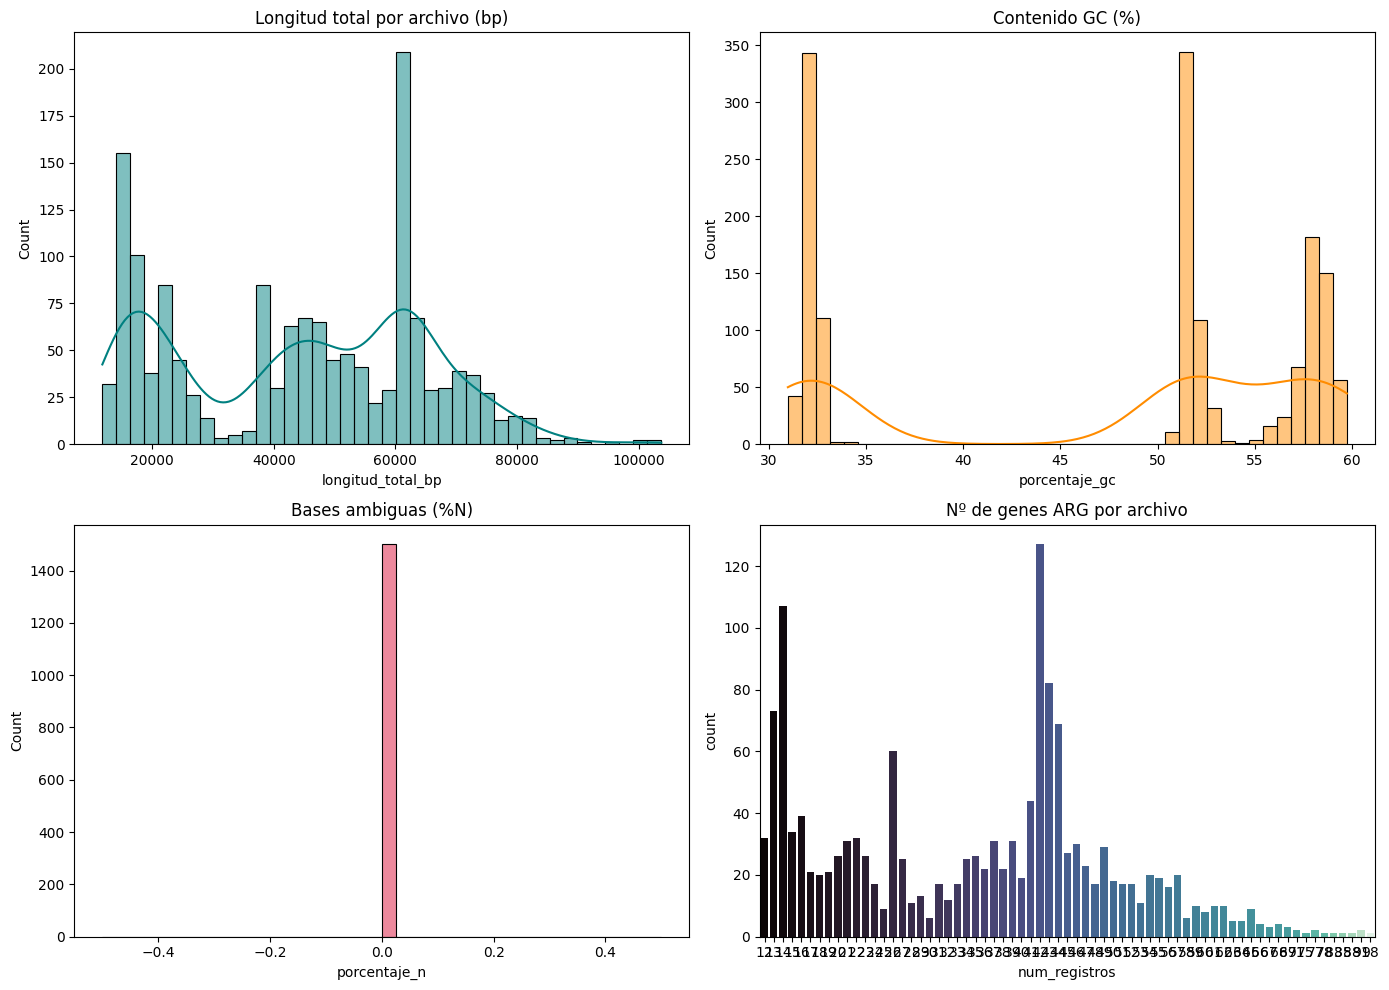

In [ ]:
resultados = []
for filepath in glob.glob(os.path.join(OUTPUT_ARG_DIR, "*.fasta")):
    nombre_archivo = os.path.basename(filepath)
    longitudes, gc_counts, n_counts, total_bases, n_seqs = [], 0, 0, 0, 0
    for record in SeqIO.parse(filepath, "fasta"):
        n_seqs += 1
        seq_str = str(record.seq).upper()
        l = len(seq_str)
        longitudes.append(l)
        gc_counts += seq_str.count("G") + seq_str.count("C")
        n_counts += seq_str.count("N")
        total_bases += l

    resultados.append({
        "archivo": nombre_archivo,
        "num_registros": n_seqs,
        "longitud_total_bp": sum(longitudes),
        "longitud_promedio_bp": np.mean(longitudes) if longitudes else 0,
        "porcentaje_gc": (gc_counts / total_bases * 100) if total_bases else 0,
        "porcentaje_n": (n_counts / total_bases * 100) if total_bases else 0,
    })

df_eda = pd.DataFrame(resultados)
df_eda.to_csv(os.path.join(DATA_DIR, "eda_fase1_resumen_secuencias.csv"), index=False)

print(f"Total de archivos analizados: {len(df_eda)}\n")
print(df_eda[["longitud_total_bp", "longitud_promedio_bp", "porcentaje_gc", "porcentaje_n", "num_registros"]].describe())

print("\nDistribución del nº de genes ARG por muestra:")
print(df_eda["num_registros"].value_counts().sort_index())

# muestras con 0 genes ARG detectados
print(f"\nMuestras sin ningún gen ARG detectado: {(df_eda['num_registros'] == 0).sum()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df_eda["longitud_total_bp"], ax=axes[0, 0], kde=True, color="teal", bins=40)
axes[0, 0].set_title("Longitud total por archivo (bp)")
sns.histplot(df_eda["porcentaje_gc"], ax=axes[0, 1], kde=True, color="darkorange", bins=40)
axes[0, 1].set_title("Contenido GC (%)")
sns.histplot(df_eda["porcentaje_n"], ax=axes[1, 0], kde=True, color="crimson", bins=40)
axes[1, 0].set_title("Bases ambiguas (%N)")
sns.countplot(data=df_eda, x="num_registros", ax=axes[1, 1], hue="num_registros", palette="mako", legend=False)
axes[1, 1].set_title("Nº de genes ARG por archivo")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "eda_fase1_graficos.png"), dpi=300)
plt.show()


See README for the summary of this EDA step.

## 3.2 Breakdown by species

In [ ]:
df_eda_meta = df_eda.copy()
df_eda_meta["id_sample"] = df_eda_meta["archivo"].str.replace(".fasta", "", regex=False)
df_meta = pd.read_csv(SUBSET_CSV_PATH)
df_eda_meta = df_eda_meta.merge(df_meta[["id_sample", "organism"]], on="id_sample", how="left")

print(df_eda_meta.groupby("organism")[["porcentaje_gc", "longitud_total_bp", "num_registros"]].describe().T)

organism                 Escherichia coli  Klebsiella pneumoniae  \
porcentaje_gc     count        500.000000             500.000000   
                  mean          51.682142              58.030697   
                  std            0.490564               0.828786   
                  min           50.675937              54.884844   
                  25%           51.368985              57.684828   
                  50%           51.466832              58.124838   
                  75%           51.900169              58.598944   
                  max           54.089250              59.744429   
longitud_total_bp count        500.000000             500.000000   
                  mean       66461.304000           46726.370000   
                  std         7608.209167            7285.882281   
                  min        46724.000000           32823.000000   
                  25%        61277.250000           41661.500000   
                  50%        62476.000000       

See README for the summary of this EDA step.

## 3.3 Comparison against the initial (keyword-based) target

        num_registros  porcentaje_gc  longitud_total_bp
target                                                 
0           34.646820      47.367536       44021.357240
1           34.775296      47.230934       44121.645204

Recuento por clase:
target
1    761
0    739
Name: count, dtype: int64


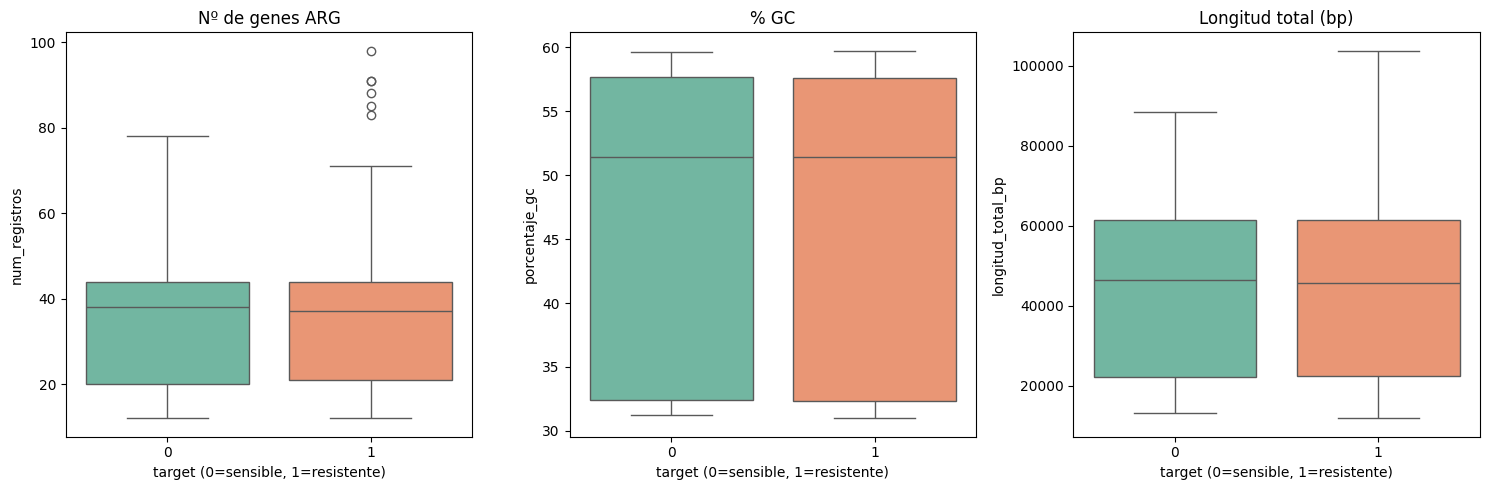

In [ ]:
df_eda_meta = df_eda.copy()
df_eda_meta["id_sample"] = df_eda_meta["archivo"].str.replace(".fasta", "", regex=False)
df_meta = pd.read_csv(SUBSET_CSV_PATH)
df_eda_meta = df_eda_meta.merge(df_meta[["id_sample", "organism", "target"]], on="id_sample", how="left")

print(df_eda_meta.groupby("target")[["num_registros", "porcentaje_gc", "longitud_total_bp"]].mean())
print("\nRecuento por clase:")
print(df_eda_meta["target"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, titulo in zip(
    axes,
    ["num_registros", "porcentaje_gc", "longitud_total_bp"],
    ["Nº de genes ARG", "% GC", "Longitud total (bp)"]
):
    sns.boxplot(data=df_eda_meta, x="target", y=col, ax=ax, hue="target", palette="Set2", legend=False)
    ax.set_title(titulo)
    ax.set_xlabel("target (0=sensible, 1=resistente)")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "eda_fase2_comparacion_target.png"), dpi=300)
plt.show()

See README for the summary of this comparison.

# Phase 4: Resistance labelling

Two steps:
1. Per-species core (intrinsic) genes: a gene is considered intrinsic to a species if it appears in >=95% of its samples; it carries no acquired-resistance signal.
2. Multi-label resistance target: for each sample, take the Abricate hits that are not core genes and use the `RESISTANCE` column directly to build one label per drug class.

## 4.1 Per-species core genes (>=95% presence)

In [ ]:
df_meta = pd.read_csv(SUBSET_CSV_PATH)
id_to_organism = dict(zip(df_meta["id_sample"], df_meta["organism"]))

genes_por_especie = defaultdict(lambda: defaultdict(int))
total_por_especie = defaultdict(int)

for sample_id, grupo in df_hits_all.groupby("id_sample"):
    organism = id_to_organism.get(sample_id)
    if organism is None:
        continue
    total_por_especie[organism] += 1
    for gene in set(grupo["GENE"]):
        genes_por_especie[organism][gene] += 1

UMBRAL_CORE = 0.95
genes_core = set()
print(f"================ GENES 'CORE' POR ESPECIE (>= {UMBRAL_CORE:.0%}) ================")
for organism, genes_count in genes_por_especie.items():
    total = total_por_especie[organism]
    core_esta_especie = [g for g, c in genes_count.items() if c / total >= UMBRAL_CORE]
    print(f"\n{organism} (n={total}): {len(core_esta_especie)} genes core")
    genes_core.update(core_esta_especie)

print(f"\nTotal de genes considerados core (a excluir): {len(genes_core)}")


================ GENES 'CORE' POR ESPECIE (>= 95%) ================

Klebsiella pneumoniae (n=500): 21 genes core

Staphylococcus aureus (n=500): 12 genes core

Escherichia coli (n=500): 39 genes core

Total de genes considerados core (a excluir): 61


## 4.2 Multi-label resistance target

In [ ]:
df_hits_adquiridos = df_hits_all[~df_hits_all["GENE"].isin(genes_core)].copy()

# Conversión del texto RESISTANCE en una lista de clases por fila
df_hits_adquiridos["RESISTANCE"] = df_hits_adquiridos["RESISTANCE"].fillna("").astype(str)
df_hits_adquiridos["clases_farmaco"] = df_hits_adquiridos["RESISTANCE"].apply(
    lambda s: [c.strip() for c in s.split(";") if c.strip()] if s else []
)

# Target binario simple: ¿tiene al menos un gen ARG adquirido (no-core)?
resumen = (
    df_hits_adquiridos.groupby("id_sample")
    .agg(n_genes_adquiridos=("GENE", "nunique"),
         clases_farmaco=("clases_farmaco", lambda x: sorted(set(c for lst in x for c in lst))))
    .reset_index()
)
resumen["target_resistencia"] = (resumen["n_genes_adquiridos"] > 0).astype(int)

df_target = df_meta.merge(resumen, on="id_sample", how="left")
df_target["n_genes_adquiridos"] = df_target["n_genes_adquiridos"].fillna(0).astype(int)
df_target["target_resistencia"] = df_target["target_resistencia"].fillna(0).astype(int)
df_target["clases_farmaco"] = df_target["clases_farmaco"].apply(lambda x: x if isinstance(x, list) else [])

df_target.to_csv(os.path.join(DATA_DIR, "metadata_target_resistencia.csv"), index=False)

print(df_target["target_resistencia"].value_counts())
print("\nClases de fármaco más frecuentes:")
print(Counter(c for lst in df_target["clases_farmaco"] for c in lst).most_common(20))


target_resistencia
1    1470
0      30
Name: count, dtype: int64

Clases de fármaco más frecuentes:
[('cephalosporin', 1278), ('penicillin_beta-lactam', 1181), ('phenicol', 979), ('fluoroquinolone', 972), ('disinfecting_agents_and_antiseptics', 961), ('phosphonic_acid', 905), ('aminoglycoside', 893), ('tetracycline', 788), ('macrolide', 752), ('diaminopyrimidine', 730), ('monobactam', 694), ('lincosamide', 648), ('carbapenem', 594), ('sulfonamide', 564), ('nucleoside', 544), ('nonribosomal_peptides', 524), ('peptide', 524), ('glycylcycline', 524), ('rifamycin', 501), ('nitrofuran', 476)]


*(Initial pass: see README, section "Methodological decisions", for why the 95% threshold and the binary target were revisited.)*

### 4.2.1 Investigating the threshold

In [ ]:
# Frecuencia de los genes que más aportan a "adquiridos"
genes_top_adquiridos = df_hits_adquiridos["GENE"].value_counts().head(20)
print(genes_top_adquiridos)

print("\nFrecuencia relativa por especie de esos genes (para ver si están justo bajo el 95%):")
for gene in genes_top_adquiridos.index[:8]:
    for organism in genes_por_especie:
        count = genes_por_especie[organism].get(gene, 0)
        total = total_por_especie[organism]
        if count > 0:
            print(f"  {gene:35s} | {organism:25s} | {count}/{total} = {count/total:.1%}")

GENE
qacEdelta1                    613
sul1                          604
oqxA                          478
ramA                          475
oqxB                          475
mdtM                          446
FosA6                         445
TEM-1                         423
ugd                           391
Staphylococcus_aureus_FosB    373
APH(6)-Id                     365
APH(3'')-Ib                   364
sul2                          364
AAC(6')-Ib10                  363
tet(A)                        360
CTX-M-15                      354
Escherichia_coli_emrE         351
aadA2                         314
mecA                          279
Mrx                           262
Name: count, dtype: int64

Frecuencia relativa por especie de esos genes (para ver si están justo bajo el 95%):
  qacEdelta1                          | Klebsiella pneumoniae     | 287/500 = 57.4%
  qacEdelta1                          | Escherichia coli          | 140/500 = 28.0%
  sul1                             

*(Empirical investigation of the 95% threshold; see README for the outcome and references.)*

### 4.2.2 Choosing the final threshold

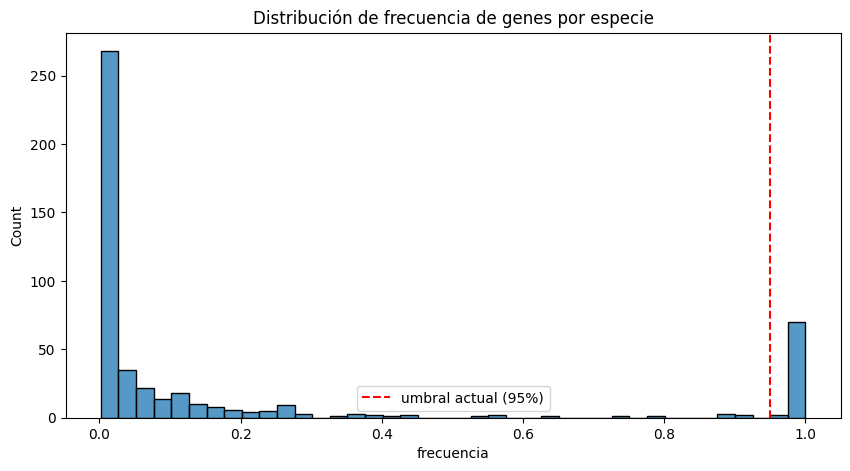

                  organism                        gene  frecuencia
5    Klebsiella pneumoniae                        ramA       0.924
29   Klebsiella pneumoniae                        oqxA       0.902
21   Klebsiella pneumoniae                        oqxB       0.896
328       Escherichia coli                        mdtM       0.892
2    Klebsiella pneumoniae                       FosA6       0.890
348       Escherichia coli                         ugd       0.782
238  Staphylococcus aureus  Staphylococcus_aureus_FosB       0.746
339       Escherichia coli       Escherichia_coli_emrE       0.650


In [ ]:
# Frecuencia relativa de TODOS los genes, por especie, para ver la distribución completa
filas_freq = []
for organism, genes_count in genes_por_especie.items():
    total = total_por_especie[organism]
    for gene, count in genes_count.items():
        filas_freq.append({"organism": organism, "gene": gene, "frecuencia": count / total})

df_freq = pd.DataFrame(filas_freq)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df_freq, x="frecuencia", bins=40, ax=ax)
ax.axvline(0.95, color="red", linestyle="--", label="umbral actual (95%)")
ax.set_title("Distribución de frecuencia de genes por especie")
ax.legend()
plt.savefig(os.path.join(DATA_DIR, "genes_core_distribucion_frecuencia.png"), dpi=300)
plt.show()

# ¿Hay un hueco claro entre "core" y "acquired"?
print(df_freq[(df_freq["frecuencia"] >= 0.60) & (df_freq["frecuencia"] < 0.95)]
      .sort_values("frecuencia", ascending=False))

See README, "Methodological decisions", for how the 60% threshold was chosen.

### 4.2.3 Re-running with the new threshold

In [ ]:
UMBRAL_CORE = 0.60
genes_core = set()
print(f"================ GENES 'CORE' POR ESPECIE (>= {UMBRAL_CORE:.0%}) ================")
for organism, genes_count in genes_por_especie.items():
    total = total_por_especie[organism]
    core_esta_especie = [g for g, c in genes_count.items() if c / total >= UMBRAL_CORE]
    print(f"\n{organism} (n={total}): {len(core_esta_especie)} genes core")
    genes_core.update(core_esta_especie)

print(f"\nTotal de genes considerados core (a excluir): {len(genes_core)}")

================ GENES 'CORE' POR ESPECIE (>= 60%) ================

Klebsiella pneumoniae (n=500): 25 genes core

Staphylococcus aureus (n=500): 13 genes core

Escherichia coli (n=500): 42 genes core

Total de genes considerados core (a excluir): 69


Re-run of section 4.2 with the updated 60% threshold.

In [ ]:
df_hits_adquiridos = df_hits_all[~df_hits_all["GENE"].isin(genes_core)].copy()

# Conversión del texto RESISTANCE en una lista de clases por fila
df_hits_adquiridos["RESISTANCE"] = df_hits_adquiridos["RESISTANCE"].fillna("").astype(str)
df_hits_adquiridos["clases_farmaco"] = df_hits_adquiridos["RESISTANCE"].apply(
    lambda s: [c.strip() for c in s.split(";") if c.strip()] if s else []
)

# Target binario simple: ¿tiene al menos un gen ARG adquirido (no-core)?
resumen = (
    df_hits_adquiridos.groupby("id_sample")
    .agg(n_genes_adquiridos=("GENE", "nunique"),
         clases_farmaco=("clases_farmaco", lambda x: sorted(set(c for lst in x for c in lst))))
    .reset_index()
)
resumen["target_resistencia"] = (resumen["n_genes_adquiridos"] > 0).astype(int)

df_target = df_meta.merge(resumen, on="id_sample", how="left")
df_target["n_genes_adquiridos"] = df_target["n_genes_adquiridos"].fillna(0).astype(int)
df_target["target_resistencia"] = df_target["target_resistencia"].fillna(0).astype(int)
df_target["clases_farmaco"] = df_target["clases_farmaco"].apply(lambda x: x if isinstance(x, list) else [])

df_target.to_csv(os.path.join(DATA_DIR, "metadata_target_resistencia.csv"), index=False)

print(df_target["target_resistencia"].value_counts())
print("\nClases de fármaco más frecuentes:")
print(Counter(c for lst in df_target["clases_farmaco"] for c in lst).most_common(20))


target_resistencia
1    1421
0      79
Name: count, dtype: int64

Clases de fármaco más frecuentes:
[('cephalosporin', 1276), ('penicillin_beta-lactam', 1180), ('aminoglycoside', 893), ('sulfonamide', 564), ('diaminopyrimidine', 560), ('monobactam', 527), ('tetracycline', 507), ('macrolide', 506), ('disinfecting_agents_and_antiseptics', 456), ('azole', 407), ('imidazole', 407), ('carbapenem', 370), ('phenicol', 343), ('fluoroquinolone', 335), ('streptogramin', 320), ('lincosamide', 228), ('nonribosomal_peptides', 191), ('peptide', 191), ('glycopeptide', 133), ('phosphonic_acid', 122)]


See README for why the threshold adjustment alone was not enough.

### 4.2.4 Identifying the dominant genes directly

In [ ]:
# ¿Qué genes concretos aportan resistencia a cephalosporin / penicillin_beta-lactam?
mask = df_hits_adquiridos["clases_farmaco"].apply(lambda lst: "cephalosporin" in lst or "penicillin_beta-lactam" in lst)
genes_beta_lactam = df_hits_adquiridos[mask]["GENE"].value_counts().head(20)
print(genes_beta_lactam)

print("\nFrecuencia por especie de esos genes:")
for gene in genes_beta_lactam.index[:10]:
    for organism in genes_por_especie:
        count = genes_por_especie[organism].get(gene, 0)
        total = total_por_especie[organism]
        if count > 0:
            print(f"  {gene:35s} | {organism:25s} | {count}/{total} = {count/total:.1%}")

GENE
TEM-1                                   423
CTX-M-15                                354
mecA                                    279
PC1_beta-lactamase_(blaZ)               200
OXA-1                                   195
PC1                                     155
EC-18                                   146
SHV-182                                 139
KPC-2                                   133
EC-15                                   119
SHV-12                                  100
TEM-150                                  94
mecA-type_mecI                           89
mecR1                                    88
SHV-187                                  84
OXA-9                                    83
NDM-1                                    80
Escherichia_coli_ampC_beta-lactamase     79
SHV-106                                  77
EC-5                                     70
Name: count, dtype: int64

Frecuencia por especie de esos genes:
  TEM-1                               | Klebsiella

See README, "Methodological decisions" (binary target -> multi-label), for the interpretation of this result.

### 4.2.5 Prevalence by drug class

In [ ]:
mlb = MultiLabelBinarizer()
y_multilabel = mlb.fit_transform(df_target["clases_farmaco"])
df_labels = pd.DataFrame(y_multilabel, columns=mlb.classes_, index=df_target["id_sample"])

balance_por_clase = df_labels.mean().sort_values(ascending=False)
print(balance_por_clase)

cephalosporin                          0.850667
penicillin_beta-lactam                 0.786667
aminoglycoside                         0.595333
sulfonamide                            0.376000
diaminopyrimidine                      0.373333
monobactam                             0.351333
tetracycline                           0.338000
macrolide                              0.337333
disinfecting_agents_and_antiseptics    0.304000
azole                                  0.271333
imidazole                              0.271333
carbapenem                             0.246667
phenicol                               0.228667
fluoroquinolone                        0.223333
streptogramin                          0.213333
lincosamide                            0.152000
peptide                                0.127333
nonribosomal_peptides                  0.127333
glycopeptide                           0.088667
phosphonic_acid                        0.081333
rifamycin                              0

Three bands emerge: too dominant (>75%, little discriminative signal), too rare (<2%, too few positives to train on), and a workable range (~5-75%, see README for the final class count).

### 4.2.6 Final multi-label target

In [ ]:
CLASE_MIN = 0.05
CLASE_MAX = 0.75

clases_seleccionadas = balance_por_clase[
    (balance_por_clase >= CLASE_MIN) & (balance_por_clase <= CLASE_MAX)
].index.tolist()

print(f"Clases seleccionadas para el target multi-etiqueta ({len(clases_seleccionadas)}):")
print(clases_seleccionadas)

df_labels_final = df_labels[clases_seleccionadas]
df_target_final = df_target[["id_sample", "organism"]].merge(
    df_labels_final, left_on="id_sample", right_index=True
)
df_target_final.to_csv(os.path.join(DATA_DIR, "metadata_target_resistencia_multilabel.csv"), index=False)

print(f"\nForma final: {df_target_final.shape}")
df_target_final.head()

Clases seleccionadas para el target multi-etiqueta (20):
['aminoglycoside', 'sulfonamide', 'diaminopyrimidine', 'monobactam', 'tetracycline', 'macrolide', 'disinfecting_agents_and_antiseptics', 'azole', 'imidazole', 'carbapenem', 'phenicol', 'fluoroquinolone', 'streptogramin', 'lincosamide', 'peptide', 'nonribosomal_peptides', 'glycopeptide', 'phosphonic_acid', 'rifamycin', 'nucleoside']

Forma final: (1500, 22)


,id_sample,organism,aminoglycoside,sulfonamide,diaminopyrimidine,monobactam,tetracycline,macrolide,disinfecting_agents_and_antiseptics,azole,...,phenicol,fluoroquinolone,streptogramin,lincosamide,peptide,nonribosomal_peptides,glycopeptide,phosphonic_acid,rifamycin,nucleoside
0,GCF_000418345.1,Staphylococcus aureus,1,0,0,0,1,1,0,0,...,1,0,1,1,0,0,0,0,0,1
1,GCF_000597965.1,Staphylococcus aureus,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,GCF_000626615.2,Staphylococcus aureus,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,GCF_000695215.1,Staphylococcus aureus,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,GCF_000695875.1,Staphylococcus aureus,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Output: a CSV with `id_sample`, `organism` and one column per drug class (`metadata_target_resistencia_multilabel.csv`).

# Phase 5: Evolutionary lineage assignment

For the 3 species, standard typing schemes widely used in bacterial epidemiology (MLST - Multi-Locus Sequence Typing) assign each genome a Sequence Type (ST) from the allelic variants of a set of housekeeping genes. ST is used here as a proxy for evolutionary lineage, assigned automatically per species with `mlst`.

## 5.1 Install `mlst`

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [ ]:
import os
import re
import json
import glob
import time
import shutil
import gzip
import tarfile
import subprocess
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from itertools import product
from numpy.lib.stride_tricks import sliding_window_view

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score, multilabel_confusion_matrix, average_precision_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
!mamba install -y -c bioconda -c conda-forge mlst
!mlst --version


[+] 0.0s
[+] 0.0s
[+] 0.1s
conda-forge/linux-64   1%
conda-forge/noarch     1%
bioconda/linux-64      1%
bioconda/noarch       ⣾  [+] 0.2s
conda-forge/linux-64   6%
conda-forge/noarch     7%
bioconda/linux-64     31%
bioconda/noarch       22%[+] 0.3s
conda-forge/linux-64   9%
conda-forge/noarch    14%
bioconda/linux-64     66%
bioconda/noarch       56%[+] 0.4s
conda-forge/linux-64  12%
conda-forge/noarch    20%
bioconda/linux-64     94%
bioconda/noarch       83%bioconda/linux-64                                 
bioconda/noarch                                   
[+] 0.5s
conda-forge/linux-64  15%
conda-forge/noarch    24%[+] 0.6s
conda-forge/linux-64  20%
conda-forge/noarch    30%[+] 0.7s
conda-forge/linux-64  23%
conda-forge/noarch    42%[+] 0.8s
conda-forge/linux-64  27%
conda-forge/noarch    52%[+] 0.9s
conda-forge/linux-64  33%
conda-forge/noarch    64%[+] 1.0s
conda-forge/linux-64  38%
conda-forge/noarch    74%[+] 1.1s
conda-forge/linux-64  43%
conda-forge/noarch    83%[+] 1.2s
con

In [ ]:
DATA_DIR = "./data"  # set this to your own data folder
os.makedirs(DATA_DIR, exist_ok=True)

# Fase 1
LOCAL_FASTA_DIR = "/content/fasta_1500"
CSV_PATH = os.path.join(DATA_DIR, "metadata_1500.csv")
CLEAN_CSV_PATH = os.path.join(DATA_DIR, "metadata_clean.csv")
SUBSET_CSV_PATH = os.path.join(DATA_DIR, "metadata_1500.csv")
FASTA_DIR = os.path.join(DATA_DIR, "fasta_1500")

# Fase 2
OUTPUT_ARG_DIR = os.path.join(DATA_DIR, "fasta_arg")
HITS_CSV_PATH = os.path.join(DATA_DIR, "abricate_hits.csv")

# Fase 4/5
MLST_CSV_PATH = os.path.join(DATA_DIR, "mlst_resultados.csv")

print("Rutas reconstruidas. FASTA_DIR:", FASTA_DIR)
print("Existe:", os.path.exists(FASTA_DIR), "| Archivos:", len(os.listdir(FASTA_DIR)) if os.path.exists(FASTA_DIR) else 0)

## 5.2 Assign a Sequence Type (ST) to each genome

In [ ]:
MLST_CSV_PATH = os.path.join(DATA_DIR, "mlst_resultados.csv")
LOTES_DIR = os.path.join(DATA_DIR, "mlst_lotes")
os.makedirs(LOTES_DIR, exist_ok=True)

genome_files = sorted(glob.glob(os.path.join(FASTA_DIR, "*.fasta")))
print(f"Genomas a tipificar: {len(genome_files)}")

BATCH = 100
n_lotes = (len(genome_files) - 1) // BATCH + 1

for lote_idx in range(n_lotes):
    lote_csv = os.path.join(LOTES_DIR, f"lote_{lote_idx:03d}.csv")

    if os.path.exists(lote_csv):
        print(f" Lote {lote_idx + 1}/{n_lotes} ya procesado, se salta.")
        continue

    i = lote_idx * BATCH
    batch_files = genome_files[i:i + BATCH]
    cmd = ["mlst", "--csv"] + batch_files
    result = subprocess.run(cmd, capture_output=True, text=True)
    lines = result.stdout.strip().split("\n")

    filas_lote = []
    for line in lines[1:]:
        parts = line.split(",")
        if len(parts) < 3:
            continue
        filepath, scheme, st = parts[0], parts[1], parts[2]
        sample_id = os.path.basename(filepath).replace(".fasta", "")
        filas_lote.append({"id_sample": sample_id, "mlst_scheme": scheme, "ST": st})

    pd.DataFrame(filas_lote).to_csv(lote_csv, index=False)
    print(f" Procesado lote {lote_idx + 1}/{n_lotes}")

# Consolidar todos los lotes en el CSV final
lotes_files = sorted(glob.glob(os.path.join(LOTES_DIR, "lote_*.csv")))
df_mlst = pd.concat([pd.read_csv(f) for f in lotes_files], ignore_index=True)
df_mlst.to_csv(MLST_CSV_PATH, index=False)

print(f"\nTotal tipificado: {len(df_mlst)} genomas")
print(df_mlst["ST"].value_counts().head(20))

Genomas a tipificar: 1500
 Procesado lote 1/15
 Procesado lote 2/15
 Procesado lote 3/15
 Procesado lote 4/15
 Procesado lote 5/15
 Procesado lote 6/15
 Procesado lote 7/15
 Procesado lote 8/15
 Procesado lote 9/15
 Procesado lote 10/15
 Procesado lote 11/15
 Procesado lote 12/15
 Procesado lote 13/15
 Procesado lote 14/15
 Procesado lote 15/15

Total tipificado: 1485 genomas
ST
8        52
8        52
14464    46
5        46
11       45
10       33
5        32
-        29
15       26
14464    25
30       25
131      25
10       21
1        19
147      17
14       15
147      15
48       15
167      15
45       14
Name: count, dtype: int64


15 genomes were lost (1,500 -> 1,485) and a few STs appear twice (8, 5, 10, 147, 14464); investigated below.

### 5.2.1 Investigating the missing genomes

In [ ]:
ids_esperados = {os.path.basename(f).replace(".fasta", "") for f in genome_files}
ids_obtenidos = set(df_mlst["id_sample"])
faltantes = ids_esperados - ids_obtenidos
print(f"Genomas sin resultado de MLST: {len(faltantes)}")
print(faltantes)

Genomas sin resultado de MLST: 15
{'GCF_002310555.1', 'GCF_006364775.1', 'GCF_003354565.1', 'GCF_002089075.2', 'GCF_003044015.1', 'GCF_002850275.3', 'GCF_011022255.1', 'GCF_001298325.2', 'GCF_012970625.1', 'GCF_003006175.1', 'GCF_009739825.1', 'GCF_001708225.1', 'GCF_000364385.3', 'GCF_001901445.1', 'GCF_003812105.1'}


### 5.2.2 Root cause

In [ ]:
faltantes = {'GCF_002310555.1', 'GCF_006364775.1', 'GCF_003354565.1', 'GCF_002089075.2',
             'GCF_003044015.1', 'GCF_002850275.3', 'GCF_011022255.1', 'GCF_001298325.2',
             'GCF_012970625.1', 'GCF_003006175.1', 'GCF_009739825.1', 'GCF_001708225.1',
             'GCF_000364385.3', 'GCF_001901445.1', 'GCF_003812105.1'}

archivos_faltantes = [os.path.join(FASTA_DIR, f"{acc}.fasta") for acc in faltantes]

for f in archivos_faltantes:
    print(f"--- {os.path.basename(f)} ---")
    print(f"  Existe: {os.path.exists(f)} | Tamaño: {os.path.getsize(f) if os.path.exists(f) else 'N/A'}")
    res = subprocess.run(["mlst", "--csv", f], capture_output=True, text=True)
    print(f"  STDOUT: {res.stdout.strip()}")
    if res.stderr.strip():
        print(f"  STDERR: {res.stderr.strip()[:300]}")
    print()

--- GCF_002310555.1.fasta ---
  Existe: True | Tamaño: 5063528
  STDOUT: ./data/fasta_1500/GCF_002310555.1.fasta,ecoli_achtman_4,539,adk(6),fumC(19),gyrB(57),icd(18),mdh(9),purA(13),recA(6)
  STDERR: This is mlst 2.35.0 running on linux with Perl 5.032001
Checking mlst dependencies:
Found 'blastn' => /usr/local/bin/blastn
Found 'any2fasta' => /usr/local/bin/any2fasta
Excluding 4 schemes: ecoli vcholerae_2 abaumannii senterica_achtman_2
Running: any2fasta -q ./data\/fasta

--- GCF_006364775.1.fasta ---
  Existe: True | Tamaño: 3033933
  STDOUT: ./data/fasta_1500/GCF_006364775.1.fasta,saureus,247,arcC(3),aroE(3),glpF(1),gmk(12),pta(4),tpi(4),yqiL(16)
  STDERR: This is mlst 2.35.0 running on linux with Perl 5.032001
Checking mlst dependencies:
Found 'blastn' => /usr/local/bin/blastn
Found 'any2fasta' => /usr/local/bin/any2fasta
Excluding 4 schemes: abaumannii senterica_achtman_2 ecoli vcholerae_2
Running: any2fasta -q ./data\/fasta

--- GCF_003354565.1.fasta ---
  Existe: True | Tamaño: 2

See README for the parsing bug that caused this and the fix applied.

### 5.2.3 Reprocessing the affected files

In [ ]:
faltantes = {'GCF_002310555.1', 'GCF_006364775.1', 'GCF_003354565.1', 'GCF_002089075.2',
             'GCF_003044015.1', 'GCF_002850275.3', 'GCF_011022255.1', 'GCF_001298325.2',
             'GCF_012970625.1', 'GCF_003006175.1', 'GCF_009739825.1', 'GCF_001708225.1',
             'GCF_000364385.3', 'GCF_001901445.1', 'GCF_003812105.1'}

archivos_faltantes = [os.path.join(FASTA_DIR, f"{acc}.fasta") for acc in faltantes]

cmd = ["mlst", "--csv"] + archivos_faltantes
result = subprocess.run(cmd, capture_output=True, text=True)
lines = result.stdout.strip().split("\n")

filas_recuperadas = []
for line in lines:  # SIN el [1:] esta vez
    parts = line.split(",")
    if len(parts) < 3:
        continue
    filepath, scheme, st = parts[0], parts[1], parts[2]
    sample_id = os.path.basename(filepath).replace(".fasta", "")
    filas_recuperadas.append({"id_sample": sample_id, "mlst_scheme": scheme, "ST": st})

df_recuperados = pd.DataFrame(filas_recuperadas)
print(f"Recuperados: {len(df_recuperados)} de {len(faltantes)}")

df_mlst = pd.read_csv(MLST_CSV_PATH)
df_mlst_completo = pd.concat([df_mlst, df_recuperados], ignore_index=True).drop_duplicates(subset="id_sample")
df_mlst_completo.to_csv(MLST_CSV_PATH, index=False)

print(f"Total final: {len(df_mlst_completo)}")

Recuperados: 15 de 15
Total final: 1500


### 5.2.4 Investigating the duplicated STs

Checking whether the duplicated ST numbers are a formatting issue, or whether ST numbering is not comparable across species (each species has its own scheme, so ST8 in *S. aureus* is not the same lineage as ST8 in *E. coli*).

In [ ]:
print(df_mlst.groupby(["mlst_scheme", "ST"]).size().sort_values(ascending=False).head(20))

mlst_scheme      ST   
saureus          8        104
                 5         78
ecoli_achtman_4  14464     71
                 10        53
klebsiella       11        42
                 147       32
saureus          30        31
klebsiella       15        27
ecoli_achtman_4  131       25
                 167       21
klebsiella       14        19
saureus          398       19
                 1         18
                 239       16
ecoli_achtman_4  11        15
                 11307     14
                 410       14
saureus          -         14
klebsiella       23        14
                 307       13
dtype: int64


Confirmed: grouping by `mlst_scheme` + `ST` removes the apparent duplication, which was caused by different species sharing the same ST number under different schemes.

### 5.2.5 Cleaning up before grouping rare STs

Two issues to resolve before grouping rare STs into a joint class:

1. `ST = "-"` is not a lineage; it means `mlst` could not type that sample under the matching scheme. Counting how many cases:

In [ ]:
print(df_mlst[df_mlst["ST"] == "-"].groupby("mlst_scheme").size())
print(f"\nTotal no tipificables: {(df_mlst['ST'] == '-').sum()} de {len(df_mlst)}")

mlst_scheme
cfreundii           1
ecoli_achtman_4     4
klebsiella          9
salmonella          1
saureus            14
dtype: int64

Total no tipificables: 29 de 1485


### 5.2.6 Choosing the grouping threshold

2. Before fixing the sample-count threshold for a ST to count as its own class, the full per-species distribution needs to be examined; the cut-off depends on each species' sample size and total number of distinct STs.

In [ ]:
conteo_st = df_mlst[df_mlst["ST"] != "-"].groupby(["mlst_scheme", "ST"]).size()
for scheme in conteo_st.index.get_level_values("mlst_scheme").unique():
    sub = conteo_st.loc[scheme].sort_values(ascending=False)
    print(f"\n{scheme}: {len(sub)} STs distintos, {sub.sum()} muestras")
    print(f"  STs con >=10 muestras: {(sub >= 10).sum()} (cubren {sub[sub>=10].sum()} muestras)")
    print(f"  STs con 1 sola muestra: {(sub == 1).sum()}")


cfreundii: 3 STs distintos, 6 muestras
  STs con >=10 muestras: 0 (cubren 0 muestras)
  STs con 1 sola muestra: 1

ecoli_achtman_4: 182 STs distintos, 564 muestras
  STs con >=10 muestras: 11 (cubren 256 muestras)
  STs con 1 sola muestra: 115

klebsiella: 118 STs distintos, 403 muestras
  STs con >=10 muestras: 11 (cubren 207 muestras)
  STs con 1 sola muestra: 71

salmonella: 1 STs distintos, 12 muestras
  STs con >=10 muestras: 1 (cubren 12 muestras)
  STs con 1 sola muestra: 0

saureus: 95 STs distintos, 486 muestras
  STs con >=10 muestras: 9 (cubren 302 muestras)
  STs con 1 sola muestra: 47


A bigger issue surfaces here: 5 schemes appear for only 3 species, and the counts don't match the expected 500/500/500 split. `mlst` assigns whichever scheme best matches the housekeeping genes present, regardless of the declared species. This is resolved by cross-checking the detected scheme against the declared species in the original metadata.

### 5.2.7 Cross-checking scheme vs. declared species

In [ ]:
df_meta = pd.read_csv(SUBSET_CSV_PATH)
df_mlst_meta = df_mlst.merge(df_meta[["id_sample", "organism"]], on="id_sample", how="left")
print(pd.crosstab(df_mlst_meta["organism"], df_mlst_meta["mlst_scheme"]))

mlst_scheme            cfreundii  ecoli_achtman_4  klebsiella  salmonella  \
organism                                                                    
Escherichia coli               7              480           0          13   
Klebsiella pneumoniae          0               88         412           0   
Staphylococcus aureus          0                0           0           0   

mlst_scheme            saureus  
organism                        
Escherichia coli             0  
Klebsiella pneumoniae        0  
Staphylococcus aureus      500  


### 5.2.8 Applying the filter

Keep only samples where the detected scheme matches the declared species, and drop non-typeable STs.

In [ ]:
esquema_esperado = {
    "Escherichia coli": "ecoli_achtman_4",
    "Klebsiella pneumoniae": "klebsiella",
    "Staphylococcus aureus": "saureus",
}

df_mlst_meta["esquema_correcto"] = df_mlst_meta.apply(
    lambda row: row["mlst_scheme"] == esquema_esperado.get(row["organism"]), axis=1
)

df_mlst_valido = df_mlst_meta[df_mlst_meta["esquema_correcto"] & (df_mlst_meta["ST"] != "-")].copy()
print(f"Muestras válidas para el target de linaje: {len(df_mlst_valido)} de {len(df_mlst_meta)}")
print(df_mlst_valido.groupby("organism").size())

Muestras válidas para el target de linaje: 1365 de 1500
organism
Escherichia coli         476
Klebsiella pneumoniae    403
Staphylococcus aureus    486
dtype: int64


Result: 1,365 of the original 1,500 samples retained (91%).

## 5.3 From ST to workable classes for classification

With hundreds of distinct STs, many represented by only one or two samples, a direct multiclass classifier on the raw ST would not be viable. What remains is choosing the sample-count threshold below which a ST is grouped into a joint "other" class.

In [ ]:
UMBRAL_ST = 10

conteo_st_valido = df_mlst_valido.groupby(["organism", "ST"]).size()

def asignar_linaje(row):
    count = conteo_st_valido.loc[(row["organism"], row["ST"])]
    return row["ST"] if count >= UMBRAL_ST else "otros"

df_mlst_valido["linaje"] = df_mlst_valido.apply(asignar_linaje, axis=1)

print(df_mlst_valido.groupby("organism")["linaje"].value_counts())

LINAJE_CSV_PATH = os.path.join(DATA_DIR, "metadata_target_linaje.csv")
df_mlst_valido[["id_sample", "organism", "ST", "linaje"]].to_csv(LINAJE_CSV_PATH, index=False)
print(f"\nGuardado en {LINAJE_CSV_PATH}")

organism               linaje
Escherichia coli       otros     306
                       10         53
                       131        25
                       167        21
                       11         15
                       410        14
                       21         11
                       405        11
                       617        10
                       95         10
Klebsiella pneumoniae  otros     196
                       11         43
                       147        33
                       15         27
                       14         19
                       23         15
                       307        14
                       16         12
                       48         12
                       258        11
                       37         11
                       340        10
Staphylococcus aureus  otros     184
                       8         104
                       5          79
                       30         31
        

Per-species class counts (see README for the final numbers used in modelling).

# Phase 6: Feature engineering and modelling

With the resistance target (`metadata_target_resistencia_multilabel.csv`, Phase 4) and lineage target (`metadata_target_linaje.csv`, Phase 5) defined, the next step is building the numeric feature representations used to train the models.

## 6.1 Feature engineering

K-mer frequencies are used as the feature representation: counting every possible k-mer in a genome produces a vector that acts as a genomic "fingerprint". k=6 is computed over the full genome of each sample (not over the trimmed ARG sequences), to get a raw sequence representation. A k-mer and its reverse complement represent the same genomic region read on the opposite DNA strand, so they are counted as a single canonical k-mer.

### 6.1.1 Building the vocabulary

In [ ]:
BASE_TO_INT = {"A": 0, "C": 1, "G": 2, "T": 3}
INT_TO_BASE = {v: k for k, v in BASE_TO_INT.items()}

def kmer_to_code(kmer):
    code = 0
    for base in kmer:
        code = code * 4 + BASE_TO_INT[base]
    return code

def code_to_kmer(code, k):
    bases = []
    for _ in range(k):
        bases.append(INT_TO_BASE[code % 4])
        code //= 4
    return "".join(reversed(bases))

def reverse_complement(kmer):
    comp = {"A": "T", "C": "G", "G": "C", "T": "A"}
    return "".join(comp[b] for b in reversed(kmer))

def build_canonical_vocab(k):
    n_total = 4 ** k
    canon_map = np.zeros(n_total, dtype=np.int32)   # code -> índice canónico
    canonical_kmers = []
    seen = {}
    for code in range(n_total):
        kmer = code_to_kmer(code, k)
        rc = reverse_complement(kmer)
        canonical = min(kmer, rc)
        if canonical not in seen:
            seen[canonical] = len(canonical_kmers)
            canonical_kmers.append(canonical)
        canon_map[code] = seen[canonical]
    return canonical_kmers, canon_map

K = 6  # 4096 codones totales -> 2080 k-mers canónicos
canonical_kmers, canon_map = build_canonical_vocab(K)
print(f"k={K}: {len(canonical_kmers)} k-mers canónicos")

k=6: 2080 k-mers canónicos


Matches the expectation (4,096 total codes / 2 ~ 2,080 canonical k-mers).

### 6.1.2 Vectorised frequency extraction for one genome

In [ ]:
def extraer_kmer_vector(fasta_path, k, canon_map, n_canonical):
    counts_totales = np.zeros(n_canonical, dtype=np.int64)
    powers = 4 ** np.arange(k - 1, -1, -1)

    for record in SeqIO.parse(fasta_path, "fasta"):
        seq = str(record.seq).upper()
        arr = np.full(len(seq), -1, dtype=np.int64)
        for base, val in BASE_TO_INT.items():
            arr[np.frombuffer(seq.encode(), dtype=np.uint8) == ord(base)] = val

        if len(arr) < k:
            continue

        windows = sliding_window_view(arr, k)
        valid = np.all(windows >= 0, axis=1)
        if not valid.any():
            continue

        codes = windows[valid] @ powers
        raw_counts = np.bincount(codes, minlength=4 ** k)
        canon_counts = np.zeros(n_canonical, dtype=np.int64)
        np.add.at(canon_counts, canon_map, raw_counts)
        counts_totales += canon_counts

    total = counts_totales.sum()
    return counts_totales / total if total > 0 else counts_totales.astype(float)

### 6.1.3 Loop over the 1,500 genomes

In [ ]:
KMER_DIR = os.path.join(DATA_DIR, f"kmer_k{K}_vectores")
os.makedirs(KMER_DIR, exist_ok=True)

def procesar_genoma_kmer(fasta_path):
    sample_id = os.path.basename(fasta_path).replace(".fasta", "")
    out_path = os.path.join(KMER_DIR, f"{sample_id}.npy")
    if os.path.exists(out_path):
        return sample_id, "SKIPPED"
    vector = extraer_kmer_vector(fasta_path, K, canon_map, len(canonical_kmers))
    np.save(out_path, vector)
    return sample_id, "OK"

df_meta = pd.read_csv(SUBSET_CSV_PATH)
genome_files = [os.path.join(FASTA_DIR, f"{acc}.fasta") for acc in df_meta["id_sample"]]

print(f"Procesando {len(genome_files)} genomas...")
with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
    futures = {executor.submit(procesar_genoma_kmer, f): f for f in genome_files}
    for idx, future in enumerate(as_completed(futures), 1):
        _, res = future.result()
        if idx % 100 == 0 or idx == len(genome_files):
            print(f" Progreso: {idx}/{len(genome_files)}")

print("Extracción de k-mers completa.")

Procesando 1500 genomas...
 Progreso: 100/1500
 Progreso: 200/1500
 Progreso: 300/1500
 Progreso: 400/1500
 Progreso: 500/1500
 Progreso: 600/1500
 Progreso: 700/1500
 Progreso: 800/1500
 Progreso: 900/1500
 Progreso: 1000/1500
 Progreso: 1100/1500
 Progreso: 1200/1500
 Progreso: 1300/1500
 Progreso: 1400/1500
 Progreso: 1500/1500
Extracción de k-mers completa.


### 6.1.4 Consolidating the feature matrix

In [ ]:
sample_ids = df_meta["id_sample"].tolist()
vectores = []
ids_ok = []
for sid in sample_ids:
    path = os.path.join(KMER_DIR, f"{sid}.npy")
    if os.path.exists(path):
        vectores.append(np.load(path))
        ids_ok.append(sid)

X_kmer = np.vstack(vectores)
df_kmer = pd.DataFrame(X_kmer, columns=canonical_kmers, index=ids_ok)
df_kmer.to_parquet(os.path.join(DATA_DIR, f"features_kmer_k{K}.parquet"))
print(f"Matriz de features: {df_kmer.shape}")

Matriz de features: (1500, 2080)


### 6.1.5 Gene-presence feature matrix

Complementary feature matrix for the resistance model: presence/absence of each detected ARG gene.

In [ ]:
df_hits_all = pd.read_csv(HITS_CSV_PATH)

df_genes_matrix = pd.crosstab(df_hits_all["id_sample"], df_hits_all["GENE"])
df_genes_matrix = (df_genes_matrix > 0).astype(int)
df_genes_matrix.to_parquet(os.path.join(DATA_DIR, "features_genes_presencia.parquet"))

print(f"Matriz de genes: {df_genes_matrix.shape}")
df_genes_matrix.head()

Matriz de genes: (1500, 372)


GENE,AAC(2')-IIa,AAC(3)-IId,AAC(3)-IIe,AAC(3)-IVa,AAC(3)-VIa,AAC(6')-I33,AAC(6')-IIa,AAC(6')-Ia,AAC(6')-Ian,AAC(6')-Ib10,...,tet(X6),ugd,vanA,vanH_gene_in_vanA_cluster,vanR_gene_in_vanA_cluster,vanS_gene_in_vanA_cluster,vanX_gene_in_vanA_cluster,vanY_gene_in_vanA_cluster,vanZ_gene_in_vanA_cluster,vgaALC
id_sample,,,,,,,,,,,,,,,,,,,,,
GCF_000364385.3,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
GCF_000418345.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_000597845.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_000597965.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCF_000599625.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Data blocks ready for modelling:
1. `features_kmer_k6.parquet` - pure sequence feature (resistance and lineage)
2. `features_genes_presencia.parquet` - interpretable feature for resistance
3. `metadata_target_resistencia_multilabel.csv` - resistance target (20 drug classes)
4. `metadata_target_linaje.csv` - lineage target (per species)

## 6.2 Models

Helper code to persist the trained models.

In [ ]:
RESULTADOS_PATH = os.path.join(DATA_DIR, "log_resultados_modelos.csv")

def registrar_resultado(nombre_modelo, f1_macro, f1_micro, notas=""):
    fila = pd.DataFrame([{
        "modelo": nombre_modelo,
        "f1_macro": f1_macro,
        "f1_micro": f1_micro,
        "notas": notas,
        "timestamp": pd.Timestamp.now(),
    }])
    if os.path.exists(RESULTADOS_PATH):
        df_log = pd.read_csv(RESULTADOS_PATH)
        df_log = pd.concat([df_log, fila], ignore_index=True)
    else:
        df_log = fila
    df_log.to_csv(RESULTADOS_PATH, index=False)
    print(f"Registrado: {nombre_modelo}")


### 6.2.1 Resistance with k-mers
A multi-label Random Forest is trained as the initial reference model for the resistance target.

In [ ]:
df_kmer = pd.read_parquet(os.path.join(DATA_DIR, f"features_kmer_k{K}.parquet"))
df_target_res = pd.read_csv(os.path.join(DATA_DIR, "metadata_target_resistencia_multilabel.csv"))
df_target_res = df_target_res.set_index("id_sample")
clases_farmaco = [c for c in df_target_res.columns if c != "organism"]

ids_comunes_res = df_kmer.index.intersection(df_target_res.index)
X_res_kmer = df_kmer.loc[ids_comunes_res]
y_res = df_target_res.loc[ids_comunes_res, clases_farmaco]

X_res_kmer_train, X_res_kmer_test, y_res_train, y_res_test = train_test_split(
    X_res_kmer, y_res, test_size=0.2, random_state=42
)

modelo_res_kmer = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
)
modelo_res_kmer.fit(X_res_kmer_train, y_res_train)
y_pred_res_kmer = pd.DataFrame(
    modelo_res_kmer.predict(X_res_kmer_test), columns=clases_farmaco, index=X_res_kmer_test.index
)

f1_macro_res_kmer = f1_score(y_res_test, y_pred_res_kmer, average="macro", zero_division=0)
f1_micro_res_kmer = f1_score(y_res_test, y_pred_res_kmer, average="micro", zero_division=0)
print(f"Resistencia (k-mers) -> F1 macro: {f1_macro_res_kmer:.3f} | F1 micro: {f1_micro_res_kmer:.3f}")

Resistencia (k-mers) -> F1 macro: 0.700 | F1 micro: 0.786


See README, "Results", for the F1 macro/micro figures and the per-class breakdown, and a species-only control model used to rule out that the result simply reflects species identity.

#### 6.2.1.1 Species-only control model

In [ ]:
# Baseline de control: ¿cuánta señal viene solo de la especie?

X_especie = pd.get_dummies(df_target_res.loc[ids_comunes_res, "organism"])
X_especie_train = X_especie.loc[X_res_kmer_train.index]
X_especie_test = X_especie.loc[X_res_kmer_test.index]

modelo_baseline = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
)
modelo_baseline.fit(X_especie_train, y_res_train)

y_pred_baseline = pd.DataFrame(
    modelo_baseline.predict(X_especie_test), columns=clases_farmaco, index=X_especie_test.index
)

f1_macro_baseline = f1_score(y_res_test, y_pred_baseline, average="macro", zero_division=0)
f1_micro_baseline = f1_score(y_res_test, y_pred_baseline, average="micro", zero_division=0)

print("F1-score por clase (baseline solo-especie) vs modelo k-mers:\n")
for clase in clases_farmaco:
    f1_b = f1_score(y_res_test[clase], y_pred_baseline[clase], zero_division=0)
    f1_k = f1_score(y_res_test[clase], y_pred_res_kmer[clase], zero_division=0)
    print(f"  {clase:38s} solo-especie={f1_b:.3f}  k-mers={f1_k:.3f}  diff={f1_k - f1_b:+.3f}")

print(f"\nBaseline (solo especie) -> F1 macro: {f1_macro_baseline:.3f} | F1 micro: {f1_micro_baseline:.3f}")
print(f"Modelo k-mers          -> F1 macro: {f1_macro_res_kmer:.3f} | F1 micro: {f1_micro_res_kmer:.3f}")

F1-score por clase (baseline solo-especie) vs modelo k-mers:

  aminoglycoside                         solo-especie=0.582  k-mers=0.903  diff=+0.321
  sulfonamide                            solo-especie=0.731  k-mers=0.875  diff=+0.144
  diaminopyrimidine                      solo-especie=0.619  k-mers=0.840  diff=+0.221
  monobactam                             solo-especie=0.680  k-mers=0.825  diff=+0.145
  tetracycline                           solo-especie=0.569  k-mers=0.814  diff=+0.246
  macrolide                              solo-especie=0.557  k-mers=0.775  diff=+0.218
  disinfecting_agents_and_antiseptics    solo-especie=0.580  k-mers=0.820  diff=+0.240
  azole                                  solo-especie=0.700  k-mers=0.783  diff=+0.083
  imidazole                              solo-especie=0.700  k-mers=0.783  diff=+0.083
  carbapenem                             solo-especie=0.568  k-mers=0.807  diff=+0.239
  phenicol                               solo-especie=0.440  k-mers=

See README, "Results", for the comparison against the species-only baseline.

#### 6.2.1.2

In [ ]:
registrar_resultado("resistencia_kmers", f1_macro_res_kmer, f1_micro_res_kmer, "RF, k=6, split 80/20")

Registrado: resistencia_kmers


### 6.2.2 Lineage modelling

In [ ]:
df_kmer = pd.read_parquet(os.path.join(DATA_DIR, f"features_kmer_k{K}.parquet"))
df_linaje = pd.read_csv(os.path.join(DATA_DIR, "metadata_target_linaje.csv"))

resultados_linaje = {}
modelos_linaje = {}

for organism in df_linaje["organism"].unique():
    print(f"\n{'='*60}\n{organism}\n{'='*60}")

    df_sub = df_linaje[df_linaje["organism"] == organism]
    ids_comunes = df_kmer.index.intersection(df_sub["id_sample"])

    X_linaje = df_kmer.loc[ids_comunes]
    y_linaje = df_sub.set_index("id_sample").loc[ids_comunes, "linaje"].astype(str)

    print(f"Muestras: {len(X_linaje)} | Clases: {y_linaje.nunique()}")
    print(y_linaje.value_counts())

    X_linaje_train, X_linaje_test, y_linaje_train, y_linaje_test = train_test_split(
        X_linaje, y_linaje, test_size=0.2, random_state=42, stratify=y_linaje
    )

    sample_weights_linaje = compute_sample_weight(class_weight="balanced", y=y_linaje_train)

    modelo_linaje = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    modelo_linaje.fit(X_linaje_train, y_linaje_train, sample_weight=sample_weights_linaje)
    modelos_linaje[organism] = modelo_linaje
    y_pred_linaje = modelo_linaje.predict(X_linaje_test)

    print(f"\nTrain: {X_linaje_train.shape} | Test: {X_linaje_test.shape}")
    print(classification_report(y_linaje_test, y_pred_linaje, zero_division=0))

    f1_macro_linaje = f1_score(y_linaje_test, y_pred_linaje, average="macro", zero_division=0)
    resultados_linaje[organism] = f1_macro_linaje
    print(f"F1 macro: {f1_macro_linaje:.3f}")

print(f"\n{'='*60}\nResumen F1 macro por especie:")
for organism, f1 in resultados_linaje.items():
    print(f"  {organism:25s} {f1:.3f}")



Staphylococcus aureus
Muestras: 486 | Clases: 10
linaje
otros    184
8        104
5         79
30        31
398       20
1         18
239       16
72        12
45        12
9         10
Name: count, dtype: int64

Train: (388, 2080) | Test: (98, 2080)
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         4
         239       1.00      1.00      1.00         3
          30       1.00      1.00      1.00         6
         398       1.00      1.00      1.00         4
          45       0.60      1.00      0.75         3
           5       0.88      0.88      0.88        16
          72       1.00      1.00      1.00         2
           8       1.00      0.90      0.95        21
           9       1.00      0.50      0.67         2
       otros       0.82      0.89      0.86        37

    accuracy                           0.89        98
   macro avg       0.93      0.87      0.88        98
weighted avg       0.90      0.89      0.89 

See README, "Results", for the per-species F1 and the discussion of low-support classes.

#### 6.2.2.1 5-fold cross-validation

In [ ]:
resultados_cv_linaje = {}

for organism in df_linaje["organism"].unique():
    df_sub = df_linaje[df_linaje["organism"] == organism]
    ids_comunes = df_kmer.index.intersection(df_sub["id_sample"])
    X_linaje = df_kmer.loc[ids_comunes]
    y_linaje = df_sub.set_index("id_sample").loc[ids_comunes, "linaje"].astype(str)

    # nº de folds limitado por la clase más pequeña (para que cada fold tenga al menos 1 de cada clase)
    min_clase = y_linaje.value_counts().min()
    n_folds = min(5, min_clase)

    modelo_linaje_cv = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    scores_linaje_cv = []
    for train_idx, test_idx in skf.split(X_linaje, y_linaje):
        X_linaje_tr, X_linaje_te = X_linaje.iloc[train_idx], X_linaje.iloc[test_idx]
        y_linaje_tr, y_linaje_te = y_linaje.iloc[train_idx], y_linaje.iloc[test_idx]
        sample_weights_linaje_cv = compute_sample_weight(class_weight="balanced", y=y_linaje_tr)
        modelo_linaje_cv.fit(X_linaje_tr, y_linaje_tr, sample_weight=sample_weights_linaje_cv)
        scores_linaje_cv.append(f1_score(y_linaje_te, modelo_linaje_cv.predict(X_linaje_te), average="macro", zero_division=0))

    resultados_cv_linaje[organism] = (np.mean(scores_linaje_cv), np.std(scores_linaje_cv), n_folds)
    print(f"{organism:25s} F1 macro CV ({n_folds}-fold): {np.mean(scores_linaje_cv):.3f} ± {np.std(scores_linaje_cv):.3f}")


Staphylococcus aureus     F1 macro CV (5-fold): 0.913 ± 0.022
Escherichia coli          F1 macro CV (5-fold): 0.791 ± 0.040
Klebsiella pneumoniae     F1 macro CV (5-fold): 0.709 ± 0.105


See README, "Results", for the cross-validated figures and the discussion of *K. pneumoniae*'s instability.

#### 6.2.3 k-mers vs. ARG genes comparison (data leakage)

In [ ]:
df_genes = pd.read_parquet(os.path.join(DATA_DIR, "features_genes_presencia.parquet"))
X_genes = df_genes.loc[df_genes.index.intersection(df_target_res.index)]

# Reutiliza los mismos índices de train/test que el modelo de k-mers para que ambas comparaciones se evalúen sobre las mismas
# muestras de test
X_genes_train = X_genes.loc[X_res_kmer_train.index]
X_genes_test = X_genes.loc[X_res_kmer_test.index]

modelo_genes = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
)
modelo_genes.fit(X_genes_train, y_res_train)

y_pred_genes = pd.DataFrame(
    modelo_genes.predict(X_genes_test), columns=clases_farmaco, index=X_genes_test.index
)

print("F1-score por clase de fármaco — k-mers vs. genes ARG (mismo test set):\n")
for clase in clases_farmaco:
    f1_k = f1_score(y_res_test[clase], y_pred_res_kmer[clase], zero_division=0)
    f1_g = f1_score(y_res_test[clase], y_pred_genes[clase], zero_division=0)
    print(f"  {clase:38s} k-mers={f1_k:.3f}  genes_ARG={f1_g:.3f}  diff={f1_g - f1_k:+.3f}")

f1_macro_genes = f1_score(y_res_test, y_pred_genes, average="macro", zero_division=0)
f1_micro_genes = f1_score(y_res_test, y_pred_genes, average="micro", zero_division=0)

print(f"\nk-mers    -> F1 macro: {f1_macro_res_kmer:.3f} | F1 micro: {f1_micro_res_kmer:.3f}")
print(f"genes ARG -> F1 macro: {f1_macro_genes:.3f} | F1 micro: {f1_micro_genes:.3f}")


F1-score por clase de fármaco — k-mers vs. genes ARG (mismo test set):

  aminoglycoside                         k-mers=0.903  genes_ARG=0.989  diff=+0.085
  sulfonamide                            k-mers=0.875  genes_ARG=0.991  diff=+0.116
  diaminopyrimidine                      k-mers=0.840  genes_ARG=0.917  diff=+0.078
  monobactam                             k-mers=0.825  genes_ARG=0.931  diff=+0.106
  tetracycline                           k-mers=0.814  genes_ARG=0.957  diff=+0.143
  macrolide                              k-mers=0.775  genes_ARG=0.995  diff=+0.220
  disinfecting_agents_and_antiseptics    k-mers=0.820  genes_ARG=0.988  diff=+0.168
  azole                                  k-mers=0.783  genes_ARG=0.897  diff=+0.113
  imidazole                              k-mers=0.783  genes_ARG=0.897  diff=+0.113
  carbapenem                             k-mers=0.807  genes_ARG=0.870  diff=+0.063
  phenicol                               k-mers=0.705  genes_ARG=0.917  diff=+0.212
  fl

See README, "Methodological decisions" (data leakage), for why this comparison is not valid evidence and is kept only as an internal consistency check.

## 6.3 Validation

F1 macro/micro can hide the type of error the model makes, which matters for a resistance problem: a false negative (predicting "susceptible" when the sample is resistant) is the clinically dangerous error, while a false positive is comparatively cheaper. False negatives/positives per class are examined here, together with PR-AUC (more informative than ROC-AUC for this heavily imbalanced setting).

In [ ]:
# Matriz de confusión por clase sobre las predicciones ya calculadas del modelo de k-mers
cm_por_clase = multilabel_confusion_matrix(y_res_test, y_pred_res_kmer)

# Probabilidades por clase necesarias para el PR-AUC
probas_res_kmer = modelo_res_kmer.predict_proba(X_res_kmer_test)  # lista de arrays, uno por clase de fármaco

print(f"{'Clase':38s} {'Prevalencia':>11s} {'FN':>5s} {'FP':>5s} {'PR-AUC':>8s}")
for i, clase in enumerate(clases_farmaco):
    tn, fp, fn, tp = cm_por_clase[i].ravel()
    prevalencia = y_res_test[clase].mean()
    pr_auc = average_precision_score(y_res_test[clase], probas_res_kmer[i][:, 1])
    print(f"{clase:38s} {prevalencia:11.1%} {fn:5d} {fp:5d} {pr_auc:8.3f}")

Clase                                  Prevalencia    FN    FP   PR-AUC
aminoglycoside                               58.3%    16    18    0.960
sulfonamide                                  37.7%    15    13    0.929
diaminopyrimidine                            36.0%    19    15    0.907
monobactam                                   33.7%    21    13    0.868
tetracycline                                 34.3%    24    12    0.889
macrolide                                    33.7%    27    16    0.898
disinfecting_agents_and_antiseptics          26.7%    14    15    0.890
azole                                        24.7%    18    13    0.854
imidazole                                    24.7%    18    13    0.854
carbapenem                                   20.7%    16     6    0.889
phenicol                                     21.3%    21    15    0.747
fluoroquinolone                              20.3%    19     9    0.832
streptogramin                                21.0%    21     2  

See README, "Methodological decisions" (error type), for the false-negative/false-positive pattern and how PR-AUC should be read relative to each class's prevalence.

## 6.4 Productionisation

### 6.4.1 Persisting the trained models

In [ ]:
# Etiqueta de especie: ya está en el propio dataset (df_target_res["organism"])
y_especie_kmer = df_target_res.loc[df_kmer.index, "organism"]

X_especie_kmer_train, X_especie_kmer_test, y_especie_kmer_train, y_especie_kmer_test = train_test_split(
    df_kmer, y_especie_kmer, test_size=0.2, random_state=42, stratify=y_especie_kmer
)

modelo_especie_kmer = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
modelo_especie_kmer.fit(X_especie_kmer_train, y_especie_kmer_train)
y_pred_especie_kmer = modelo_especie_kmer.predict(X_especie_kmer_test)

print(classification_report(y_especie_kmer_test, y_pred_especie_kmer))

                       precision    recall  f1-score   support

     Escherichia coli       1.00      1.00      1.00       100
Klebsiella pneumoniae       1.00      1.00      1.00       100
Staphylococcus aureus       1.00      1.00      1.00       100

             accuracy                           1.00       300
            macro avg       1.00      1.00      1.00       300
         weighted avg       1.00      1.00      1.00       300



### 6.4.2 Prediction function

In [ ]:
def predecir_genoma(fasta_path):

    # 1. Extraer el vector de k-mers del genoma nuevo
    vector = extraer_kmer_vector(fasta_path, K, canon_map, len(canonical_kmers))
    X_nuevo = pd.DataFrame([vector], columns=df_kmer.columns)

    # 2. Predecir especie
    especie_predicha = modelo_especie_kmer.predict(X_nuevo)[0]

    # 3. Predecir resistencia
    resistencia_pred = pd.Series(modelo_res_kmer.predict(X_nuevo)[0], index=clases_farmaco)
    clases_resistentes = resistencia_pred[resistencia_pred == 1].index.tolist()

    # 4. Predecir linaje, con el modelo específico de la especie ya detectada
    modelo_linaje_especie = modelos_linaje[especie_predicha]
    linaje_predicho = modelo_linaje_especie.predict(X_nuevo)[0]

    return {
        "especie": especie_predicha,
        "clases_resistentes": clases_resistentes,
        "linaje_predicho": linaje_predicho,
    }

#### 6.4.3 Testing the prediction function

In [ ]:
sample_id_prueba = X_res_kmer_test.index[0]
ruta_fasta_prueba = os.path.join(FASTA_DIR, f"{sample_id_prueba}.fasta")
print(ruta_fasta_prueba)

./data/fasta_1500/GCF_001900535.1.fasta


In [ ]:
resultado_prueba = predecir_genoma(os.path.join(FASTA_DIR, "GCF_001900535.1.fasta"))
print(resultado_prueba)

In [ ]:
print("Real (resistencia):", y_res_test.loc[sample_id_prueba][y_res_test.loc[sample_id_prueba] == 1].index.tolist())
print("Real (linaje):     ", df_linaje.set_index("id_sample").loc[sample_id_prueba, "linaje"])
print("Real (especie):    ", df_linaje.set_index("id_sample").loc[sample_id_prueba, "organism"])

Real (resistencia): []
Real (linaje):      otros
Real (especie):     Escherichia coli


Consistent across all three outputs: species, resistance (empty in both cases) and lineage ("other" in both cases).